# Phase 2 - Neural Network

## 1. Import Libraries

In [66]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Sequential, callbacks
from tensorflow.keras.layers import InputLayer, Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## 2. Import Preprocessed Data

In [56]:
x_train = pd.read_csv("preprocessed/X_train_scaled.csv").to_numpy(dtype=np.float32)
x_test = pd.read_csv("preprocessed/X_test_scaled.csv").to_numpy(dtype=np.float32)
# Extracting the single label column as a 1D integer array.
y_train = pd.read_csv("preprocessed/y_train.csv").iloc[:, 0].to_numpy(dtype=np.int32)
y_test = pd.read_csv("preprocessed/y_test.csv").iloc[:, 0].to_numpy(dtype=np.int32)

print("Training", x_train.shape, y_train.shape)
print("Testing", x_test.shape, y_test.shape)

Training (1322089, 127) (1322089,)
Testing (566610, 127) (566610,)


## 3. ANN Training

### 3.1 Defining ANN Shape

In [57]:
mlp = Sequential([
    InputLayer(shape=(127,)),
    # More neurons in early layers give the network more capacity to capture complex patterns, but also increase the risk of overfitting.
    Dense(256, activation="relu"),
    # We use dropout to mitigate the risk of overfitting.
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    # Sigmoid produces a probability for this binary classification task.
    Dense(1, activation="sigmoid"),
])


### 3.2 Compiling Model

In [58]:
# Binary cross-entropy matches our 0/1 target for prediction.
mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        # AUC specifically helps judge performance on an imbalanced dataset.
        tf.keras.metrics.AUC(name="auc")
    ]
)

### 3.3. Adjusting For Class Imbalance 

In [59]:
# Using class weights to address class imbalance.
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
print(class_weight)

{np.int32(0): np.float64(3.853206223004599), np.int32(1): np.float64(0.5745555099727778)}


### 3.4 Setting Up Early Stopping

In [60]:
es = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

### 3.4. Training Model

In [61]:
history = mlp.fit(
    x_train, y_train,
    # Holding out 20% of the training set for validation.
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[es],
    verbose=1
)

Epoch 1/20
4132/4132 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.5832 - auc: 0.7065 - loss: 0.6454 - precision: 0.9289 - recall: 0.5573 - val_accuracy: 0.7437 - val_auc: 0.8125 - val_loss: 0.4394 - val_precision: 0.9692 - val_recall: 0.7439
Epoch 2/20
4132/4132 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.5952 - auc: 0.7174 - loss: 0.6374 - precision: 0.9311 - recall: 0.5709 - val_accuracy: 0.8054 - val_auc: 0.8137 - val_loss: 0.3949 - val_precision: 0.9588 - val_recall: 0.8230
Epoch 3/20
4132/4132 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6018 - auc: 0.7199 - loss: 0.6354 - precision: 0.9311 - recall: 0.5791 - val_accuracy: 0.7724 - val_auc: 0.8146 - val_loss: 0.4500 - val_precision: 0.9652 - val_recall: 0.7797
Epoch 4/20
4132/4132 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6022 - auc: 0.7219 - loss: 0.6339 - precision: 0.9317 - recall: 0.5792 - val_accuracy: 0.7684 - val_auc: 0.8158 - val_loss: 0.4535 - val_precision: 0.9662 - val_recall: 0.7744
Epoch 5/20
4132/4132 ━━━

## 4. Model Evaluation

To evaluate the neural network, We used diverse set of metrics rather than relying solely on accuracy. This is important because the Lending Club dataset is highlt imbalanced: there are a lot more non-default loans than default loans. In such settings, a model can achieve deceptively high accuracy simply by predicting the majority class.

For this reason, we measured performance using:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- AUC-ROC  
- Precision–Recall behavior

These metrics in together offer a more complete understanding of how well the model predicts low-risk and high-risk loans.

---

### Why Accuracy Alone Is Not Enough

In imbalanced classification problems, accuracy can hide important behavior. A model may have high accuracy while performing badly on the minority class or lower accuracy while doing a better job detecting rare but important outcomes.


17707/17707 ━━━━━━━━━━━━━━━━━━━━ 4s 198us/step


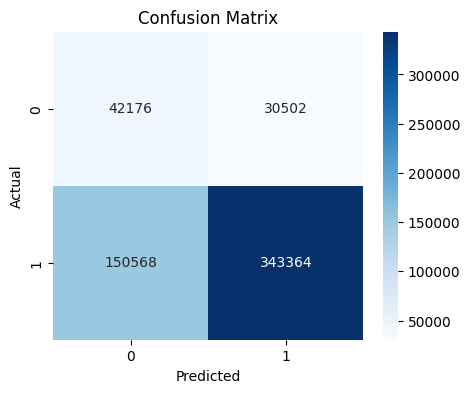


Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.58      0.32     72678
           1       0.92      0.70      0.79    493932

    accuracy                           0.68    566610
   macro avg       0.57      0.64      0.55    566610
weighted avg       0.83      0.68      0.73    566610



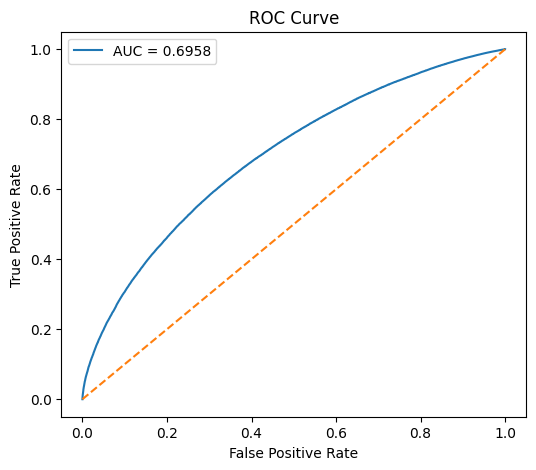

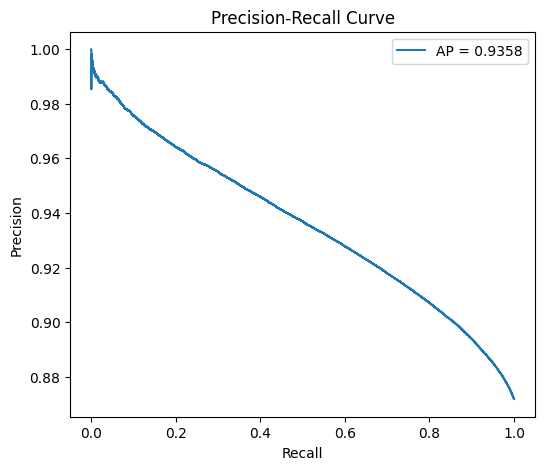

In [62]:
y_prob = mlp.predict(x_test).ravel()

# Starting with the standard 0.5 cutoff.
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
auc_roc = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {auc_roc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precisions, recalls, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
avg_precision = average_precision_score(y_test, y_prob)
plt.plot(recalls, precisions, label=f"AP = {avg_precision:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


### Training Outcome

Given the results above the model shows evidence of learning meaningful predictive patterns from the preprocessed loan data in Phase 1. Earlier in development, this model behaved like a majority-class predictor, but after scaling inputs, and applying class weights our performance improved dramatically.

The validation AUC during training reached approximately 0.82, indicating strong predicting ability and performance well above random guessing.

---

### Confusion Matrix Interpretation

At the default threshold of 0.5, the confusion matrix shows:

- The model correctly identifies a large number of non-default loans  
- It captures a meaningful portion of default-related cases  
- Some errors remain, especially false approvals and rejected good loans

Note: False positives and false negatives do not carry the same cost, making threshold selection a key part of the model strategy. Check the next section for our threshold and banking strategies' analysis.

---

### Classification Report

The classification report shows better performance on the majority class (non-default) than on the minority class (default). However, the model still achieves meaningful recall on the minority class. This is important as identifying risky loans is the major goal of this project.

---

### AUC-ROC and Ranking Performance

The model achieved a validation AUC of **0.82**, indicating strong separability and confirming that the neural network is definitely learning.

## 5. Banking Strategies

### Threshold Analysis

To better understand tradeoffs between precision and recall, the model was evaluated using several thresholds: 0.3, 0.4, 0.5, 0.6, 0.7, 0.8

These results show a clear tradeoff:

- Lower thresholds -> higher recall, higher F1-score  
- Higher thresholds -> higher precision, lower recall  

These tradeoffs confirm that we need threshold tuning. The optimal threshold depends on the business goal:

- If the goal is to identify as many risky loans as possible, choose a lower threshold  
- If the goal is to reduce false approvals and stay conservative, choose a higher threshold  

For banking purposes, a higher threshold is recommended. This ensures that loans are approved only for clients the model is confident will not default, reducing exposure to risky borrowers.

In [63]:
# Comparing several cutoffs to see how different strategies change our outcome.
# Note: We are trading recall for precision as we increase the threshold, which means we will approve fewer loans but with higher confidence.
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds_to_test:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Approved (TP+FP): {tp+fp}")
    print(f"Bad approvals (FP): {fp}")
    print("---")

Threshold: 0.3
Precision: 0.8808
Recall:    0.9699
F1 Score:  0.9232
Approved (TP+FP): 543891
Bad approvals (FP): 64823
---
Threshold: 0.4
Precision: 0.8996
Recall:    0.8607
F1 Score:  0.8797
Approved (TP+FP): 472561
Bad approvals (FP): 47451
---
Threshold: 0.5
Precision: 0.9184
Recall:    0.6952
F1 Score:  0.7913
Approved (TP+FP): 373866
Bad approvals (FP): 30502
---
Threshold: 0.6
Precision: 0.9380
Recall:    0.4868
F1 Score:  0.6410
Approved (TP+FP): 256370
Bad approvals (FP): 15905
---
Threshold: 0.7
Precision: 0.9549
Recall:    0.3005
F1 Score:  0.4572
Approved (TP+FP): 155459
Bad approvals (FP): 7008
---
Threshold: 0.8
Precision: 0.9700
Recall:    0.1467
F1 Score:  0.2548
Approved (TP+FP): 74693
Bad approvals (FP): 2238
---


## 6. Saving Results (Phase 3)

In [68]:
# Default-threshold predictions
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Main evaluation metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

summary_rows = [
    {"metric": "date", "value": datetime.now().strftime("%Y-%m-%d")},
    {"metric": "threshold", "value": threshold},
    {"metric": "accuracy", "value": accuracy_score(y_test, y_pred)},
    {"metric": "precision", "value": precision_score(y_test, y_pred)},
    {"metric": "recall", "value": recall_score(y_test, y_pred)},
    {"metric": "f1_score", "value": f1_score(y_test, y_pred)},
    {"metric": "roc_auc", "value": roc_auc_score(y_test, y_prob)},
    {"metric": "avg_precision", "value": average_precision_score(y_test, y_prob)},
    {"metric": "tn", "value": tn},
    {"metric": "fp", "value": fp},
    {"metric": "fn", "value": fn},
    {"metric": "tp", "value": tp},
]

summary_df = pd.DataFrame(summary_rows)

# Threshold sweep results
threshold_rows = []
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds_to_test:
    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    threshold_rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1_score": f1_score(y_test, y_pred_t),
        "approved_tp_fp": tp + fp,
        "bad_approvals_fp": fp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    })

threshold_df = pd.DataFrame(threshold_rows)

# File names
date_str = datetime.now().strftime("%Y-%m-%d")
summary_file = f"results/neural_network_{date_str}_summary.csv"
threshold_file = f"results/neural_network_{date_str}_thresholds.csv"

# Save
summary_df.to_csv(summary_file, index=False)
threshold_df.to_csv(threshold_file, index=False)

print(f"Saved summary to: {summary_file}")
print(f"Saved threshold results to: {threshold_file}")


Saved summary to: results/neural_network_2026-04-10_summary.csv
Saved threshold results to: results/neural_network_2026-04-10_thresholds.csv



## 7. Conclusion

The neural network can be considered successful for Phase 2. The results show that the model is learning meaningful patterns.

Key evidence of success includes:

- Validation AUC around 0.82  
- Meaningful detection of the minority (default) class  
- Strong performance at tuned thresholds  

Additionally, testing multiple thresholds shows that model evaluation should not stop at the 0.5 threshold. Understanding precision, recall, and F1 across different thresholds allows us to choose a better operating strategy for real-world credit-risk prediction.